In [44]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [38]:
labels = ['PNEUMONIA', 'NORMAL']

# IMPORTANT
# MUST MATCH MODEL INPUT SIZE
img_size = 96


In [39]:

def get_data(data_dir):

    X = []
    y = []

    for label in labels:

        path = os.path.join(data_dir, label)

        class_num = labels.index(label)

        for img in os.listdir(path):

            try:

                img_path = os.path.join(path, img)

                # Read image
                img_arr = cv2.imread(img_path)

                # Skip corrupted images
                if img_arr is None:
                    continue

                # Convert BGR to RGB
                img_arr = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB)

                # Resize image
                resized_arr = cv2.resize(img_arr, (img_size, img_size))

                X.append(resized_arr)

                y.append(class_num)

            except Exception as e:

                print(e)

    # float16 saves RAM
    X = np.array(X, dtype=np.float16)

    y = np.array(y, dtype=np.int8)

    return X, y


In [40]:
print("Loading Dataset...")

X_train, y_train = get_data("chest_xray/chest_xray/train")

X_test, y_test = get_data("chest_xray/chest_xray/test")

X_val, y_val = get_data("chest_xray/chest_xray/val")

print("Dataset Loaded Successfully")

Loading Dataset...
Dataset Loaded Successfully


In [41]:
X_train = X_train / 255.0

X_test = X_test / 255.0

X_val = X_val / 255.0




In [42]:
print(X_train.shape)

print(y_train.shape)

(5216, 96, 96, 3)
(5216,)


In [45]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=8
)

In [46]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

# Fine tuning
base_model.trainable = True

for layer in base_model.layers[:-20]:

    layer.trainable = False

In [47]:
model_01 = Sequential()

model_01.add(base_model)

model_01.add(Flatten())

model_01.add(Dense(128, activation='relu'))

model_01.add(Dropout(0.5))

model_01.add(Dense(1, activation='sigmoid'))


In [48]:
model_01.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 11520)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,474,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,732,801 (14.24 MB)

 Trainable params: 2,680,897 (10.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [49]:
filepath = "best_model.weights.h5"

es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    verbose=1,
    restore_best_weights=True
)

cp = ModelCheckpoint(
    filepath,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

lrr = ReduceLROnPlateau(
    monitor="val_accuracy",
    patience=2,
    verbose=1,
    factor=0.5,
    min_lr=1e-5
)



In [50]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.6730322580645162), 1: np.float64(1.9448173005219984)}


In [51]:
model_01.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [52]:

history = model_01.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=15,
    callbacks=[es, cp, lrr],
    class_weight=class_weights
)

Epoch 1/15
652/652 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.8059 - loss: 0.5228
Epoch 1: val_loss improved from None to 0.55112, saving model to best_model.weights.h5

Epoch 1: finished saving model to best_model.weights.h5
652/652 ━━━━━━━━━━━━━━━━━━━━ 91s 110ms/step - accuracy: 0.8472 - loss: 0.3845 - val_accuracy: 0.8125 - val_loss: 0.5511 - learning_rate: 1.0000e-04
Epoch 2/15
652/652 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8870 - loss: 0.2647
Epoch 2: val_loss improved from 0.55112 to 0.38649, saving model to best_model.weights.h5

Epoch 2: finished saving model to best_model.weights.h5
652/652 ━━━━━━━━━━━━━━━━━━━━ 64s 98ms/step - accuracy: 0.8884 - loss: 0.2596 - val_accuracy: 0.6875 - val_loss: 0.3865 - learning_rate: 1.0000e-04
Epoch 3/15
652/652 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9119 - loss: 0.2336
Epoch 3: val_loss did not improve from 0.38649
652/652 ━━━━━━━━━━━━━━━━━━━━ 59s 90ms/step - accuracy: 0.9116 - loss: 0.2296 - val_accuracy: 0.8750 - val

In [53]:
model_01.load_weights("best_model.weights.h5")

In [54]:
val_loss, val_acc = model_01.evaluate(X_val, y_val)

test_loss, test_acc = model_01.evaluate(X_test, y_test)

print("\nValidation Accuracy :", val_acc)

print("Test Accuracy :", test_acc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9375 - loss: 0.1898
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.8798 - loss: 0.3222

Validation Accuracy : 0.9375
Test Accuracy : 0.879807710647583


In [55]:
predictions = model_01.predict(X_test)

predicted_classes = []

for pred in predictions:

    if pred[0] > 0.5:

        predicted_classes.append(1)

    else:

        predicted_classes.append(0)

predicted_classes = np.array(predicted_classes)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 369ms/step


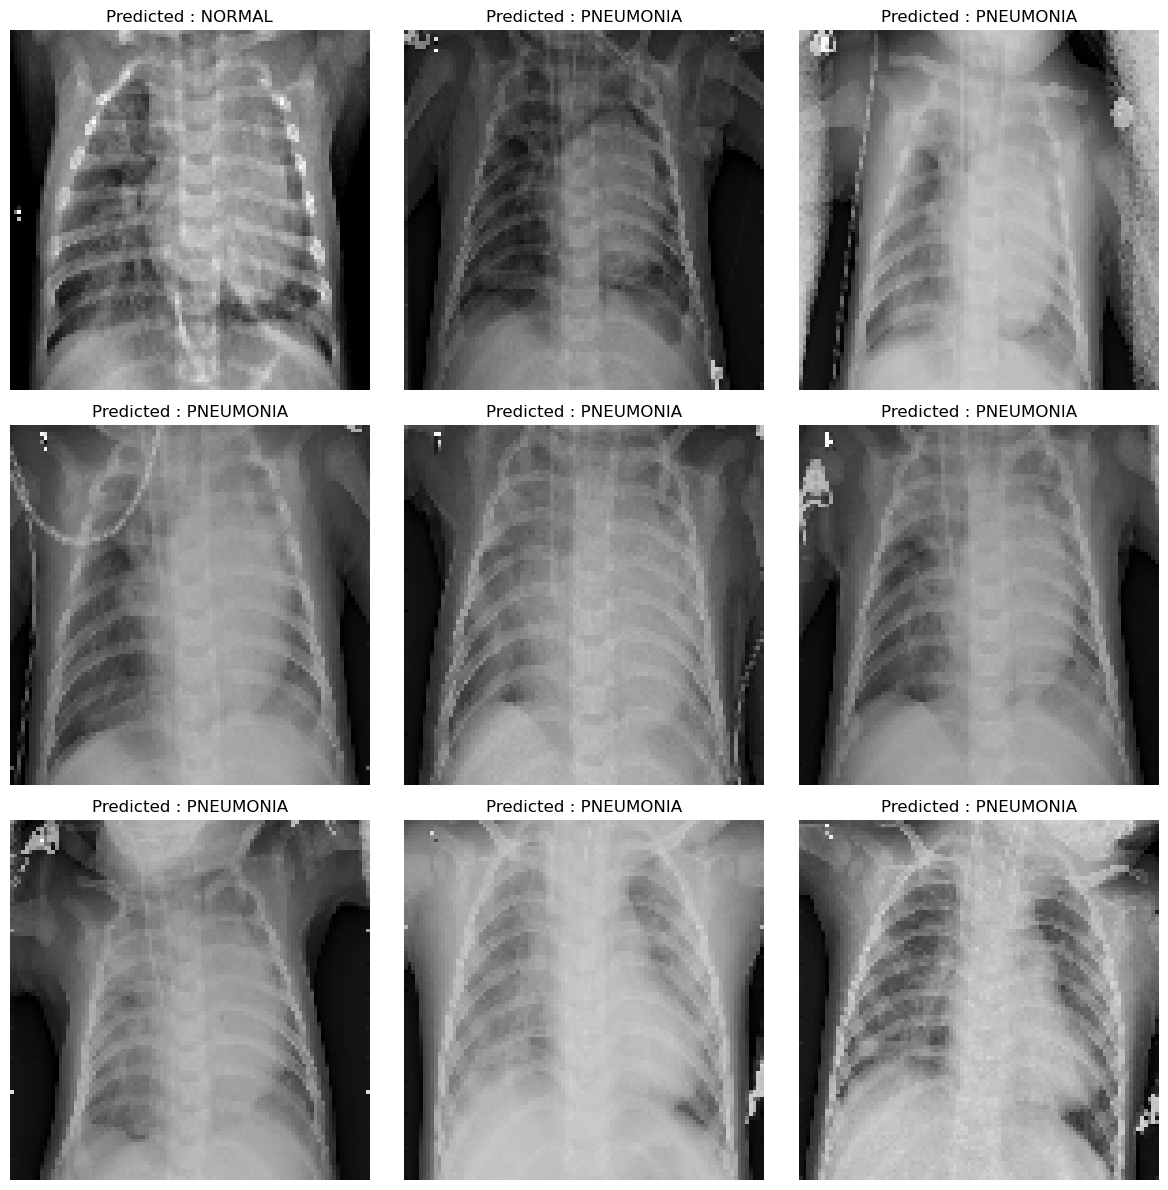

In [58]:
# =========================
# SHOW PREDICTION RESULTS
# =========================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    # Convert image to float32
    img = X_test[i].astype(np.float32)

    plt.imshow(img)

    if predicted_classes[i] == 0:

        plt.title("Predicted : PNEUMONIA")

    else:

        plt.title("Predicted : NORMAL")

    plt.axis('off')

plt.tight_layout()

plt.show()


In [59]:
model_01.save_weights("best_model.weights.h5")

print("\nModel Saved Successfully")


Model Saved Successfully
